# Divvy Ride Length Prediction

Notebook to train multiple models to predict `ride_length` using Chicago Divvy data.

**Contents:**
- Load data
- EDA & visualizations
- Feature engineering & preprocessing
- Three models: Linear Regression, Random Forest, Gradient Boosting
- Evaluation and comparison

_Run each cell sequentially in Jupyter._

In [1]:
# Cell 1: Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# display settings
pd.set_option('display.max_columns', 200)


In [2]:
# Cell 2: Load data
data = pd.read_csv('../Data/Divvy_2024_All_Months_Cleaned.csv')
print('rows, cols:', data.shape)
data.head()

rows, cols: (420816, 20)


,Unnamed: 0,ride_id,rideable_type,rideable_type_code,started_at,ended_at,ride_length,month_name,day_of_week,hour_of_day,start_station_name,start_station_id,start_lat,start_lng,end_station_name,end_station_id,end_lat,end_lng,member_casual,member_casual_code
0,0,913B85634F159906,electric_bike,1,2024-07-19 07:46:19,2024-07-19 07:53:02,6.706817,July,Friday,07 AM,Clinton St & Madison St,TA1305000032,41.882262,-87.641595,Larrabee St & Kingsbury St,TA1306000009,41.897764,-87.642884,member,1
1,1,C9BCD21A2CEBB08F,classic_bike,0,2024-07-13 19:47:19,2024-07-13 19:59:55,12.604533,July,Saturday,07 PM,Dearborn St & Adams St,TA1305000005,41.879356,-87.629791,Dearborn St & Erie St,13045,41.893992,-87.629318,member,1
2,2,FE0857D07DBC1C5E,electric_bike,1,2024-07-03 16:40:29,2024-07-03 16:54:44,14.239467,July,Wednesday,04 PM,Franklin St & Monroe St,TA1309000007,41.880817,-87.636265,Damen Ave & Division St,13136,41.903266,-87.678435,casual,0
3,3,1C776ECA65845B21,classic_bike,0,2024-07-20 23:43:30,2024-07-21 00:08:40,25.164400,July,Saturday,11 PM,Clark St & Winnemac Ave,TA1309000035,41.973348,-87.667855,Monticello Ave & Irving Park Rd,KA1504000139,41.954005,-87.719128,casual,0
4,4,FAB1DD9D1C92A55C,classic_bike,0,2024-07-29 06:00:21,2024-07-29 06:09:28,9.126233,July,Monday,06 AM,Desplaines St & Kinzie St,TA1306000003,41.888716,-87.644448,Fairbanks Ct & Grand Ave,TA1305000003,41.891847,-87.620580,member,1


In [3]:
# Cell 3: Quick dtypes & missing-check
print(data.dtypes)
print('\nMissing values per column:')
print(data.isna().sum())

Unnamed: 0              int64
ride_id                object
rideable_type          object
rideable_type_code      int64
started_at             object
ended_at               object
ride_length           float64
month_name             object
day_of_week            object
hour_of_day            object
start_station_name     object
start_station_id       object
start_lat             float64
start_lng             float64
end_station_name       object
end_station_id         object
end_lat               float64
end_lng               float64
member_casual          object
member_casual_code      int64
dtype: object

Missing values per column:
Unnamed: 0            0
ride_id               0
rideable_type         0
rideable_type_code    0
started_at            0
ended_at              0
ride_length           0
month_name            0
day_of_week           0
hour_of_day           0
start_station_name    0
start_station_id      0
start_lat             0
start_lng             0
end_station_name      

In [4]:
# Cell 4: Basic cleaning & ensure datetime/numeric
for col in ['started_at','ended_at']:
    if col in data.columns and not np.issubdtype(data[col].dtype, np.datetime64):
        data[col] = pd.to_datetime(data[col], errors='coerce')

if 'ride_length' in data.columns and not np.issubdtype(data['ride_length'].dtype, np.number):
    data['ride_length'] = pd.to_numeric(data['ride_length'], errors='coerce')

data = data.dropna(subset=['ride_length', 'started_at'])
data = data[data['ride_length'] >= 0]
print('After cleaning:', data.shape)


After cleaning: (420816, 20)


In [5]:
# Cell 5: Feature engineering
def parse_hour(x):
    try:
        if isinstance(x, (int,float)):
            return int(x)
        s = str(x).strip()
        if 'AM' in s or 'PM' in s:
            return int(pd.to_datetime(s, format='%I %p').hour)
        if ':' in s:
            return int(s.split(':')[0])
        return int(s)
    except Exception:
        return np.nan

if 'hour_of_day' in data.columns:
    data['hour'] = data['hour_of_day'].apply(parse_hour)
else:
    data['hour'] = data['started_at'].dt.hour

from math import radians, cos, sin, asin, sqrt
def haversine(lat1, lon1, lat2, lon2):
    try:
        lat1, lon1, lat2, lon2 = map(float, (lat1, lon1, lat2, lon2))
    except Exception:
        return np.nan
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    km = 6371 * c
    return km

if {'start_lat','start_lng','end_lat','end_lng'}.issubset(data.columns):
    data['trip_km'] = data.apply(lambda r: haversine(r['start_lat'], r['start_lng'], r['end_lat'], r['end_lng']), axis=1)
else:
    data['trip_km'] = np.nan

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
if 'month_name' in data.columns:
    data['month_name'] = pd.Categorical(data['month_name'], categories=month_order, ordered=True)

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
if 'day_of_week' in data.columns:
    data['day_of_week'] = pd.Categorical(data['day_of_week'], categories=weekday_order, ordered=True)

if 'rideable_type_code' not in data.columns and 'rideable_type' in data.columns:
    data['rideable_type_code'] = data['rideable_type'].map({'classic_bike':0,'electric_bike':1}).fillna(0).astype(int)

if 'member_casual_code' not in data.columns and 'member_casual' in data.columns:
    data['member_casual_code'] = data['member_casual'].map({'member':1,'casual':0}).fillna(0).astype(int)

data[['ride_length','trip_km','hour']].describe()

,ride_length,trip_km,hour
count,420816.000000,420816.000000,420816.000000
mean,16.534093,2.093628,13.980502
std,33.689269,1.890874,4.783195
min,0.000000,0.000000,0.000000
25%,5.813658,0.878210,11.000000
50%,10.104442,1.538056,15.000000
75%,18.146608,2.706331,17.000000
max,1437.009050,30.642281,23.000000


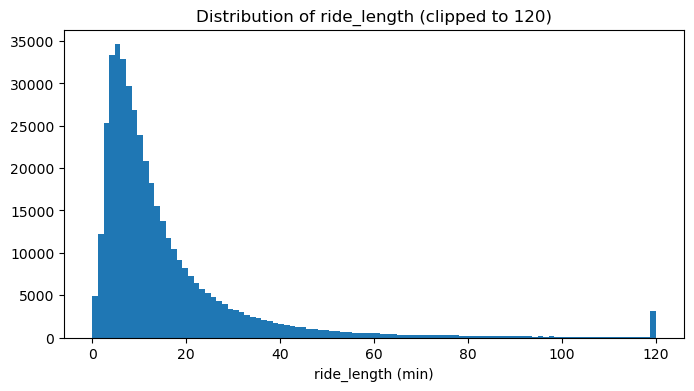

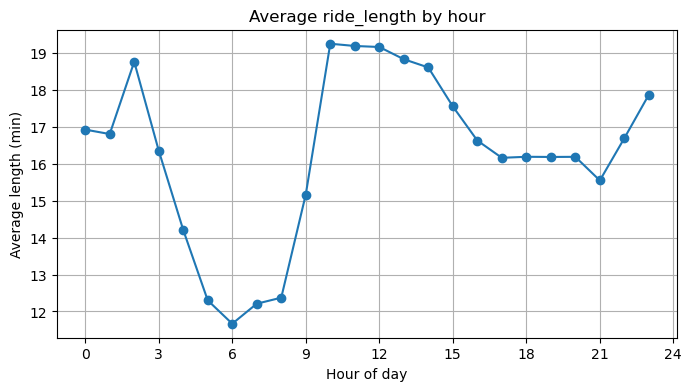

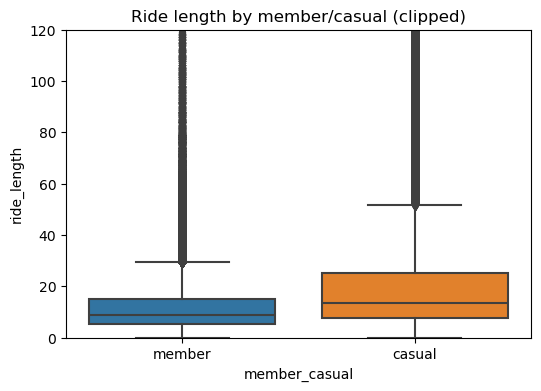

In [6]:
# Cell 6: EDA & Visualizations
plt.figure(figsize=(8,4))
plt.hist(data['ride_length'].clip(upper=120), bins=100)
plt.title('Distribution of ride_length (clipped to 120)')
plt.xlabel('ride_length (min)')
plt.show()

if 'hour' in data.columns:
    hour_avg = data.groupby('hour')['ride_length'].mean().reset_index()
    plt.figure(figsize=(8,4))
    plt.plot(hour_avg['hour'], hour_avg['ride_length'], marker='o')
    plt.title('Average ride_length by hour')
    plt.xlabel('Hour of day')
    plt.ylabel('Average length (min)')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True)
    plt.show()

if 'member_casual' in data.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='member_casual', y='ride_length', data=data.loc[data['ride_length']<200])
    plt.ylim(0,120)
    plt.title('Ride length by member/casual (clipped)')
    plt.show()


In [7]:
# Cell 7: Prepare features & split
FEATURES = ['month_name','day_of_week','hour','start_station_name','end_station_name','trip_km','rideable_type_code','member_casual_code']
X = data[FEATURES].copy()
y = data['ride_length'].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train.shape, X_test.shape


((336652, 8), (84164, 8))

In [8]:
# Cell 8: Preprocessing
# Frequency encoding for high-cardinality station names
for col in ['start_station_name','end_station_name']:
    freq = X_train[col].value_counts(normalize=True)
    X_train[col + '_freq'] = X_train[col].map(freq).fillna(0)
    X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)

MODELED_FEATURES = ['month_name','day_of_week','hour','trip_km','rideable_type_code','member_casual_code','start_station_name_freq','end_station_name_freq']

cat_cols = ['month_name','day_of_week']
num_cols = ['hour','trip_km','start_station_name_freq','end_station_name_freq','rideable_type_code','member_casual_code']

cat_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

num_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_transformer, cat_cols),
    ('num', num_transformer, num_cols)
])


In [9]:
# Cell 9: Helper functions for evaluation & plotting
def eval_and_print(model, X_test_p, y_test, prefix=''):
    y_pred = model.predict(X_test_p)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    print(f"{prefix} MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
    return y_pred, mae, rmse, r2

def plot_residuals(y_true, y_pred, title='Residuals'):
    resid = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, resid, alpha=0.3)
    plt.hlines(0, xmin=min(y_pred), xmax=max(y_pred), colors='r')
    plt.xlabel('Predicted')
    plt.ylabel('Residual (true - pred)')
    plt.title(title)
    plt.show()


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420816 entries, 0 to 420815
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Unnamed: 0          420816 non-null  int64         
 1   ride_id             420816 non-null  object        
 2   rideable_type       420816 non-null  object        
 3   rideable_type_code  420816 non-null  int64         
 4   started_at          420816 non-null  datetime64[ns]
 5   ended_at            420816 non-null  datetime64[ns]
 6   ride_length         420816 non-null  float64       
 7   month_name          420816 non-null  category      
 8   day_of_week         420816 non-null  category      
 9   hour_of_day         420816 non-null  object        
 10  start_station_name  420816 non-null  object        
 11  start_station_id    420816 non-null  object        
 12  start_lat           420816 non-null  float64       
 13  start_lng           420816 no

LinearRegression MAE: 9.601, RMSE: 32.153, R2: 0.082


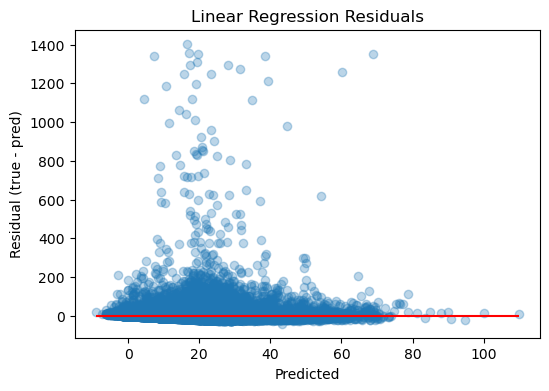

In [13]:
# Cell 10: Model 1 - Linear Regression (FIXED)
pipe_lr = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', LinearRegression())
])

# Fit using only MODELED_FEATURES (no duplicate columns)
pipe_lr.fit(X_train[MODELED_FEATURES], y_train)

# Predict
y_pred_lr = pipe_lr.predict(X_test[MODELED_FEATURES])

# Evaluate
eval_and_print(pipe_lr, X_test[MODELED_FEATURES], y_test, prefix='LinearRegression')
plot_residuals(y_test, y_pred_lr, title='Linear Regression Residuals')


In [16]:
# Cell 11: Linear model coefficients (robust feature names)
# Extract the onehot encoder and build feature names
ohe = pipe_lr.named_steps['pre'].transformers_[0][1].named_steps['onehot']
onehot_cols = list(ohe.get_feature_names_out(cat_cols))
feature_names = onehot_cols + num_cols  # num_cols is same list used in ColumnTransformer

coefs = pipe_lr.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
coef_df.head(20)


,feature,coef
16,day_of_week_Thursday,-1.237967e+10
17,day_of_week_Tuesday,-1.237967e+10
18,day_of_week_Wednesday,-1.237967e+10
12,day_of_week_Friday,-1.237967e+10
13,day_of_week_Monday,-1.237967e+10
14,day_of_week_Saturday,-1.237967e+10
15,day_of_week_Sunday,-1.237967e+10
9,month_name_November,-1.181162e+10
2,month_name_December,-1.181162e+10
7,month_name_March,-1.181162e+10


RandomForest MAE: 8.844, RMSE: 33.113, R2: 0.026


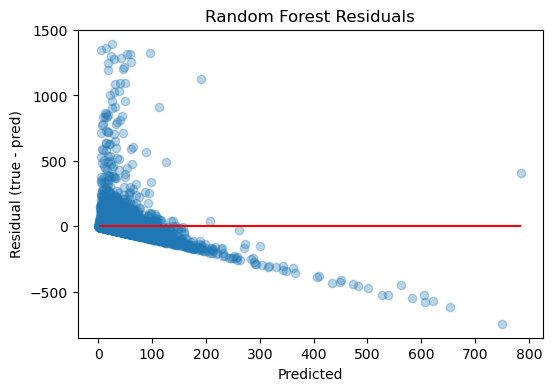

trip_km                    0.239085
end_station_name_freq      0.169816
start_station_name_freq    0.163531
hour                       0.129502
member_casual_code         0.027671
day_of_week_Wednesday      0.022056
day_of_week_Monday         0.018941
day_of_week_Saturday       0.017972
month_name_June            0.017145
day_of_week_Friday         0.016790
rideable_type_code         0.016574
month_name_July            0.016523
day_of_week_Tuesday        0.016333
month_name_October         0.015224
day_of_week_Sunday         0.015187
dtype: float64

In [17]:
# Cell 12: Model 2 - Random Forest (FIXED)
pipe_rf = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train[MODELED_FEATURES], y_train)
y_pred_rf = pipe_rf.predict(X_test[MODELED_FEATURES])
eval_and_print(pipe_rf, X_test[MODELED_FEATURES], y_test, prefix='RandomForest')
plot_residuals(y_test, y_pred_rf, title='Random Forest Residuals')

# Feature importances (built-in)
rf_model = pipe_rf.named_steps['model']
# reuse onehot_cols and num_cols from the linear coefficients cell
fi = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
fi.head(15)


In [ ]:
# Cell 13: Plot RF feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
fi.head(15).plot(kind='bar')
plt.title('Random Forest feature importances (top 15)')
plt.show()

In [ ]:
# Cell 14: Optional - Hyperparameter tuning (short grid)
param_grid = {
    'model__n_estimators': [100, 250],
    'model__max_depth': [10, 20, None],
}
search = GridSearchCV(pipe_rf, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
search.fit(X_train[MODELED_FEATURES + ['month_name','day_of_week']], y_train)
print('Best params:', search.best_params_)
print('Best CV MAE:', -search.best_score_)
best_rf = search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test[MODELED_FEATURES + ['month_name','day_of_week']])
eval_and_print(best_rf, X_test[MODELED_FEATURES + ['month_name','day_of_week']], y_test, prefix='RF (tuned)')

In [ ]:
# Cell 15: Model 3 - Gradient Boosting
pipe_gb = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42))
])

pipe_gb.fit(X_train[MODELED_FEATURES + ['month_name','day_of_week']], y_train)
y_pred_gb = pipe_gb.predict(X_test[MODELED_FEATURES + ['month_name','day_of_week']])
eval_and_print(pipe_gb, X_test[MODELED_FEATURES + ['month_name','day_of_week']], y_test, prefix='GradientBoosting')
plot_residuals(y_test, y_pred_gb, title='Gradient Boosting Residuals')

In [ ]:
# Cell 16: Compare models
results = []
for name, y_pred in [('LinearRegression', y_pred_lr), ('RandomForest', y_pred_rf), ('RF_tuned', y_pred_best_rf if 'y_pred_best_rf' in globals() else y_pred_rf), ('GradientBoosting', y_pred_gb)]:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('MAE')
results_df

In [ ]:
# Cell 17: Save best model & suggestions
import joblib
best_model = best_rf if 'best_rf' in globals() else pipe_rf
joblib.dump(best_model, 'best_divvy_model_rf.pkl')
print('Saved best model to best_divvy_model_rf.pkl')

# Suggestions:
# - Use target encoding for stations with proper CV to avoid leakage
# - Add weather and event/holiday features
# - Try XGBoost/LightGBM and tune hyperparameters further
# - Consider modeling log(ride_length) for skewed targets
